In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().absolute().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# print(PROJECT_ROOT)

In [5]:
from src.time_series import load_multi_csv, load_angles
from src.sliding_window import sliding_windows_multiplet
from src.inference import load_model, predict_multiplet, predict_classes_from_proba
from src.visual import plot_raw_multiplet, plot_multiplet_predictions, plot_angles
from src.criteria import process_multiplet

In [8]:
data_path=str(PROJECT_ROOT)+'/time_series/TOI-1136_arg_p_max_history_resonance_3_2_between_1_and_2_original_angles.csv'
data = load_angles(data_path, ['phi_0_original', 'phi_1_original'], time_column='time_years')
data

{'angles_deg': [array([ 522.60016, 1241.1411 ,  877.6311 , ...,  134.01372,  855.0923 ,
          517.0333 ], shape=(400000,), dtype=float32),
  array([ 705.6975 , 1441.9207 , 1090.5598 , ...,  360.238  , 1073.3041 ,
          725.02075], shape=(400000,), dtype=float32)],
 'angle_names': ['phi_0_original', 'phi_1_original'],
 'time_years': array([0.0000000e+00, 2.5002053e+00, 5.0001917e+00, ..., 9.9999250e+05,
        9.9999500e+05, 9.9999750e+05], shape=(400000,), dtype=float32)}

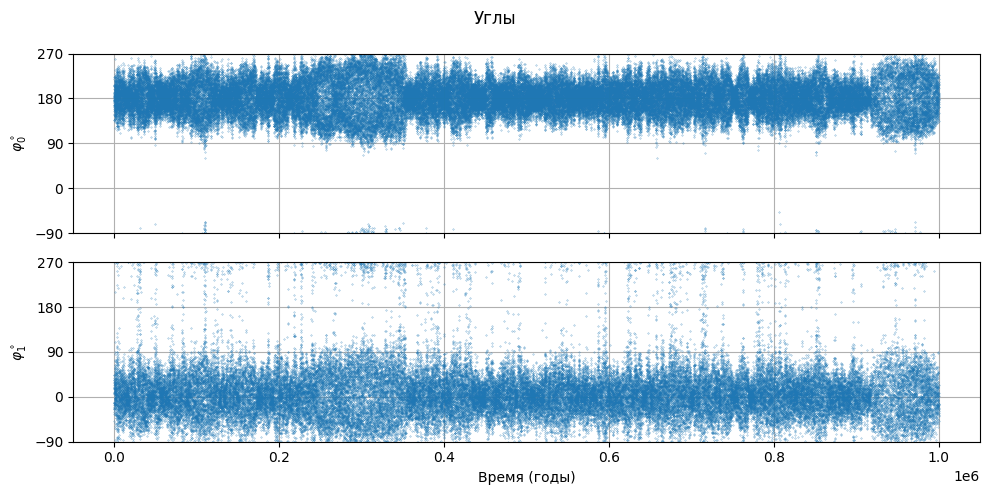

In [9]:
plot_angles(data['time_years'], data['angles_deg'], title='Углы')

In [4]:
data_path=str(PROJECT_ROOT)+'/time_series/TOI-1136_arg_p_max_history_resonance_3_2_between_1_and_2_original_angles.csv'
data = load_multi_csv(
    filepath=data_path,
    angle_columns=['phi_0_original', 'phi_1_original'],  # подставь свои имена колонок
    period_column='period_ratio',
    time_column='time_years',
    angle_unit='deg',
    convert_to_xy=True
)

In [7]:
data_path=str(PROJECT_ROOT)+'/time_series/TOI-1136_arg_p_max_history_resonance_3_2_between_1_and_2_original_angles.csv'
data_test=load_angles(
    filepath=data_path,
    angle_columns=['phi_0_original', 'phi_1_original'],
    time_column='time_years',
    angle_unit='deg',
    convert_to_xy=True,
)
    

In [8]:
data_test

{'angles_deg': [array([ 522.60016, 1241.1411 ,  877.6311 , ...,  134.01372,  855.0923 ,
          517.0333 ], shape=(400000,), dtype=float32),
  array([ 705.6975 , 1441.9207 , 1090.5598 , ...,  360.238  , 1073.3041 ,
          725.02075], shape=(400000,), dtype=float32)],
 'angle_names': ['phi_0_original', 'phi_1_original'],
 'angles_xy': [array([[-0.9542413 ,  0.29903784],
         [-0.9463175 ,  0.3232386 ],
         [-0.92475283,  0.38056824],
         ...,
         [-0.69483066,  0.71917343],
         [-0.7082444 ,  0.7059673 ],
         [-0.9207318 ,  0.39019608]], shape=(400000, 2), dtype=float32),
  array([[ 0.9690049 , -0.24704139],
         [ 0.99943817,  0.03351608],
         [ 0.9830642 ,  0.1832617 ],
         ...,
         [ 0.99999136,  0.00415389],
         [ 0.993179  , -0.11659928],
         [ 0.9961631 ,  0.08751661]], shape=(400000, 2), dtype=float32)],
 'time_years': array([0.0000000e+00, 2.5002053e+00, 5.0001917e+00, ..., 9.9999250e+05,
        9.9999500e+05, 9.999

In [17]:
print('Ключи:', data.keys())
print('Форма period_ratio:', data['period_ratio'].shape)
print('Количество углов:', len(data['angles_xy']))
print('Диапазон времени: {:.2e} – {:.2e} лет'.format(
    data['time_years'][0], data['time_years'][-1]))

Ключи: dict_keys(['time_years', 'period_ratio', 'angles_deg', 'angle_names', 'angles_xy'])
Форма period_ratio: (400000,)
Количество углов: 2
Диапазон времени: 0.00e+00 – 1.00e+06 лет


In [18]:
windows = sliding_windows_multiplet(
    data_dict=data,
    window_length=4000,
    overlap_ratio=0.
)


In [19]:
print('Число окон:', len(windows['window_bounds']))
print('Форма окон первого угла:', windows['angle_windows'][0].shape)
print('Границы первого окна (индексы):', windows['window_bounds'][0])
print('Границы последнего окна:', windows['window_bounds'][-1])

Число окон: 100
Форма окон первого угла: (100, 4000, 2)
Границы первого окна (индексы): (0, 4000)
Границы последнего окна: (396000, 400000)


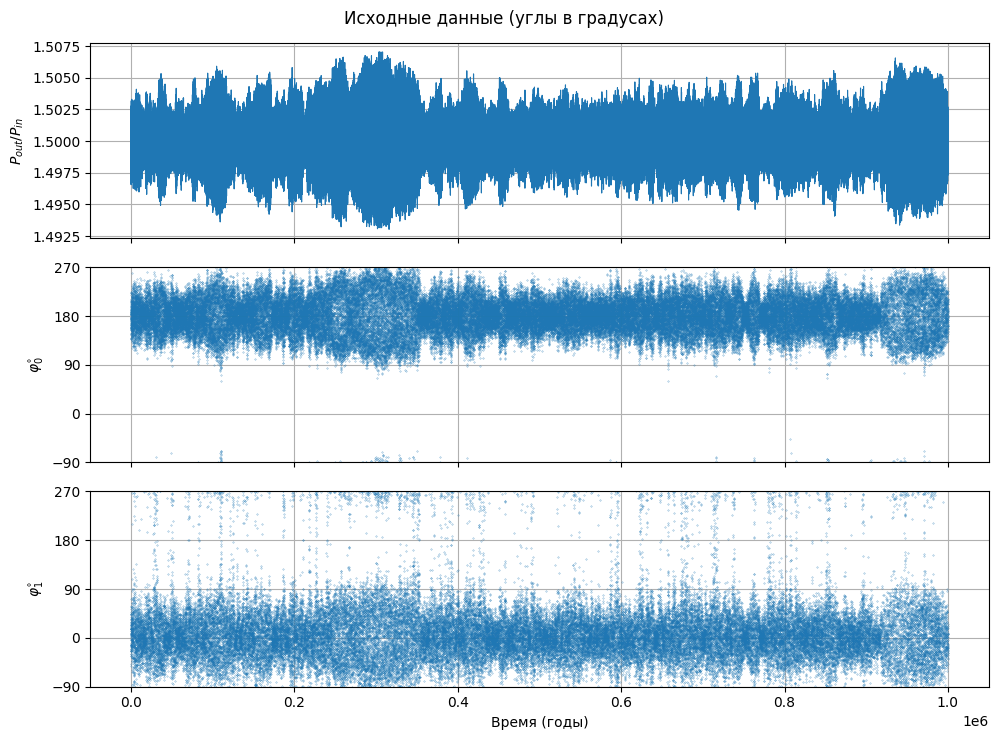

In [5]:
plot_raw_multiplet(
    time_years=data['time_years'],
    period_ratio=data['period_ratio'],
    angles_deg_list=data['angles_deg'],
    title='Исходные данные (углы в градусах)',
    # save_path=''
)

In [21]:
model = load_model('1', models_dir=str(PROJECT_ROOT)+'/models/')

W0000 00:00:1777905062.240569   41442 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [22]:
print("Число углов:", len(windows['angle_windows']))
for i, w in enumerate(windows['angle_windows']):
    print(f"Угол {i}: shape = {w.shape}, dtype = {w.dtype}")

Число углов: 2
Угол 0: shape = (100, 4000, 2), dtype = float32
Угол 1: shape = (100, 4000, 2), dtype = float32


In [14]:
# from src.inference import predict_multiplet, predict_classes_from_proba

In [23]:
probs = predict_multiplet(windows['angle_windows'], model)
# print("Число массивов вероятностей:", len(probs))
# for i, p in enumerate(probs):
#     print(f"Угол {i}: shape = {p.shape}, dtype = {p.dtype}")
#     print(f"  Суммы вероятностей по окнам (первые 5): {p[:5].sum(axis=1)}")
#     print(f"  Диапазон значений: min={p.min():.4f}, max={p.max():.4f}")

In [24]:
classes = [predict_classes_from_proba(p) for p in probs]

# import numpy as np
# for i, cls in enumerate(classes):
#     unique, counts = np.unique(cls, return_counts=True)
#     total = len(cls)
#     print(f"\nУгол {i}:")
#     for u, c in zip(unique, counts):
#         print(f"  Класс {u}: {c} окон ({100*c/total:.1f}%)")

In [25]:
n_windows = len(windows['window_bounds'])
for i, cls in enumerate(classes):
    assert len(cls) == n_windows, f"Угол {i}: классов {len(cls)}, а окон {n_windows}"
print("OK: количество классов совпадает с количеством окон для всех углов.")

OK: количество классов совпадает с количеством окон для всех углов.


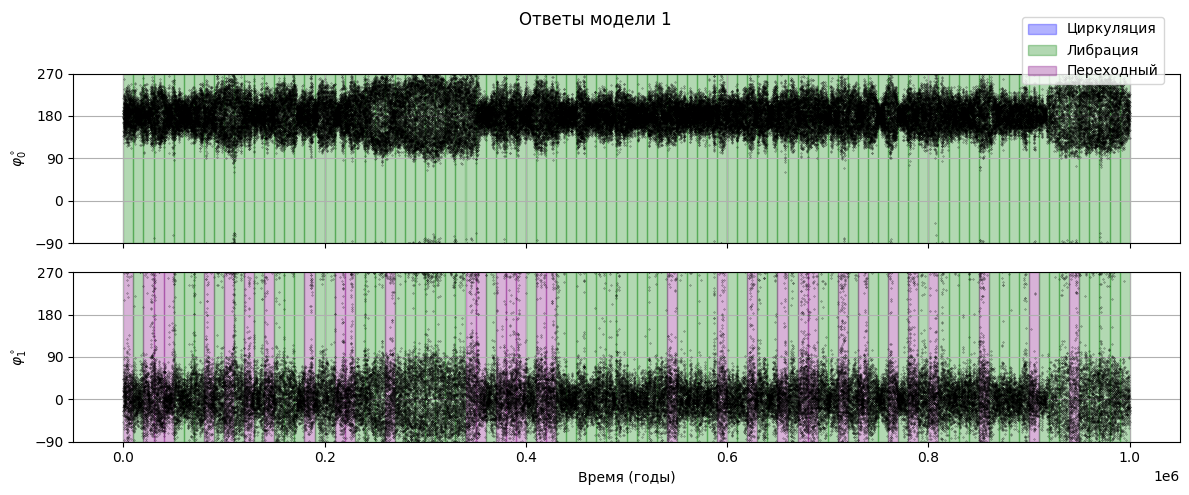

In [26]:
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes,
    title='Ответы модели 1',
    # save_path='/content/drive/MyDrive/Diplom_data/resonance_sorter/notebook/predict_TOI1136_model1.png'

)

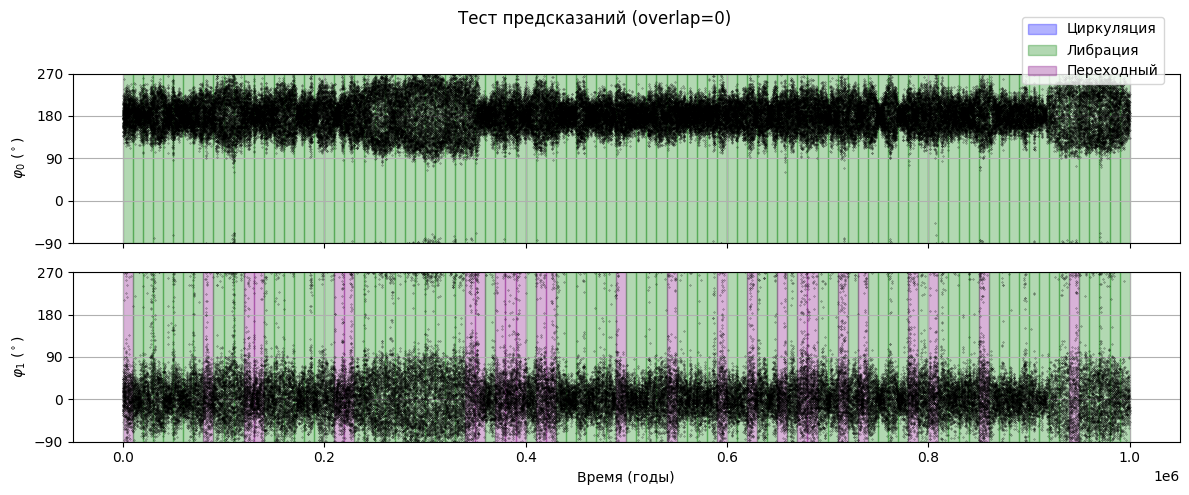

In [14]:
plot_multiplet_predictions(
    time_years=data['time_years'],
    angles_deg_list=data['angles_deg'],
    window_bounds=windows['window_bounds'],
    class_labels_list=classes,
    title='Тест предсказаний (overlap=0)'
)

In [27]:

segments = process_multiplet(
    class_labels_list=classes,
    window_bounds=windows['window_bounds'],
    time_years=data['time_years'],
    period_ratio=data['period_ratio'],
    expected_ratio=1.5,
    min_librations=30,
    max_consecutive_nonlib=2,
    sliding_window_size=6,
    max_nonlib_in_sliding=2
)

In [28]:
segments

[{'librations_count': 100,
  'start_window': 0,
  'end_window': 99,
  't_start_years': np.float32(0.0),
  't_end_years': np.float32(999997.5),
  'duration_years': np.float32(999997.5),
  'Delta_max': np.float32(0.0070397854)}]